In [11]:
from langgraph.graph import StateGraph, START,END
from typing  import TypedDict
from  pydantic import BaseModel,Field

In [12]:
class NodeState(BaseModel):
    n2:float
    product:float=0
    cube:float=0
    double:float=0


In [13]:
def input(state:NodeState):
    return{"num":state.n2}

In [14]:
def squre(state:NodeState):
    return {'product': state.n2**2}
def cube(state:NodeState):
    return{"cube":state.n2**3}
def double(state:NodeState):
    return {"double":state.n2*2}
def merge(state:NodeState):
    return{
        "product":state.product,
        "cube":state.cube,
        "double":state.double
    }

Input Number: 5
[125, 10, 25]


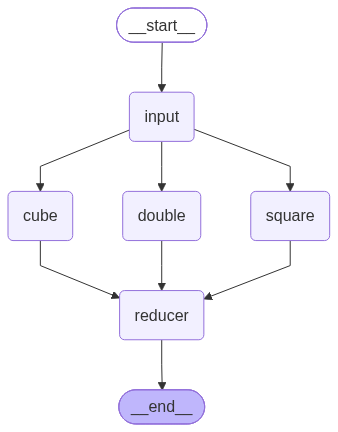

In [33]:
from langgraph.graph import StateGraph, START, END
from pydantic import BaseModel
from typing import Annotated,operator
# ---------------- State ----------------
class NodeState(BaseModel):
    n2:int
    numbers: Annotated[list[int], operator.add]
# ---------------- Nodes ----------------
def input_node(state: NodeState):
    print(f"Input Number: {state.n2}")
    return {}
def square(state: NodeState):
    return {
        "numbers": [state.n2 ** 2]
    }
def cube(state: NodeState):
    return {
        "numbers":[ state.n2 ** 3]
    }
def double(state: NodeState):
    return {
        "numbers": [state.n2 * 2]
    }
def reducer(state:NodeState)->dict:
    print(state.numbers)
    return {}
# ---------------- Graph ----------------
graph = StateGraph(NodeState)

graph.add_node("input", input_node)
graph.add_node("square", square)
graph.add_node("cube", cube)
graph.add_node("double", double)
graph.add_node("reducer", reducer)
# Start
graph.add_edge(START, "input")
# input -> square
graph.add_edge("input", "square")
# square -> cube & double (parallel)
graph.add_edge("input", "cube")
graph.add_edge("input", "double")
# both finish -> merge
graph.add_edge("square","reducer")
graph.add_edge("cube", "reducer")
graph.add_edge("double", "reducer")
# end
graph.add_edge("reducer", END)
app = graph.compile()
# ---------------- Run ----------------
result = app.invoke({
    "n2":5
})
app